# Análise de Séries Temporais para Previsão de Vendas
Este notebook apresenta uma análise completa de dados de vendas mensais, utilizando técnicas de suavização e decomposição.

,Vendas
Data,
2022-01-31,104.967142
2022-02-28,110.933205
2022-03-31,129.789257
2022-04-30,147.118995
2022-05-31,135.003146


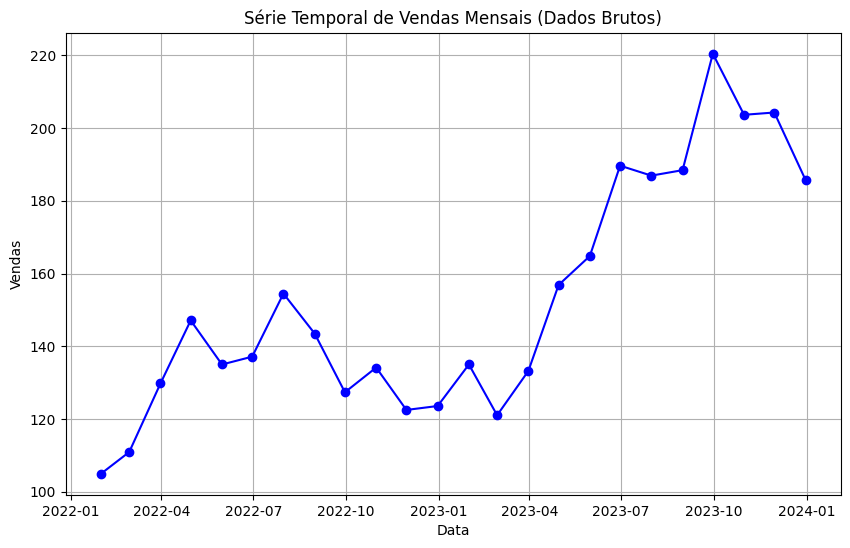

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Gerar dados fictícios de vendas mensais (24 meses)
np.random.seed(42)
# Atualizado 'M' para 'ME' para evitar FutureWarning
datas = pd.date_range(start='2022-01-01', periods=24, freq='ME')
tendencia = np.linspace(100, 200, 24)  # Tendência de crescimento
sazonalidade = 20 * np.sin(np.linspace(0, 3 * np.pi, 24))  # Padrão sazonal
ruido = np.random.normal(0, 10, 24)  # Ruído aleatório

vendas = tendencia + sazonalidade + ruido
df = pd.DataFrame({'Data': datas, 'Vendas': vendas})
df.set_index('Data', inplace=True)

# Exibir os primeiros dados
display(df.head())

# Plotar gráfico inicial
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Vendas'], marker='o', linestyle='-', color='b')
plt.title('Série Temporal de Vendas Mensais (Dados Brutos)')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.grid(True)
plt.show()

## Aplicar Técnicas de Suavização
Utilizaremos a Média Móvel para reduzir flutuações e identificar a tendência central.

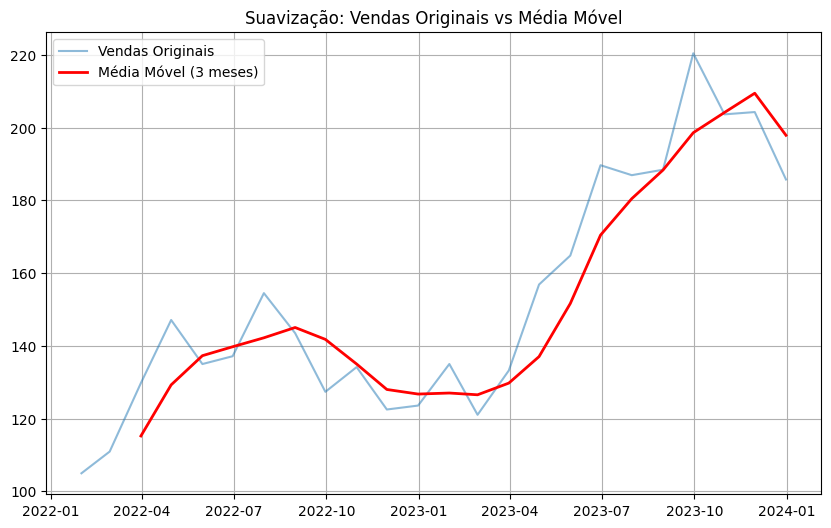

In [2]:
# Calcular Média Móvel (janela de 3 meses)
df['Media_Movel'] = df['Vendas'].rolling(window=3).mean()

# Plotar comparação
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Vendas'], label='Vendas Originais', alpha=0.5)
plt.plot(df.index, df['Media_Movel'], label='Média Móvel (3 meses)', color='red', linewidth=2)
plt.title('Suavização: Vendas Originais vs Média Móvel')
plt.legend()
plt.grid(True)
plt.show()

## Decomposição da Série Temporal
Vamos decompor a série em Tendência, Sazonalidade e Resíduos para entender melhor a estrutura dos dados.

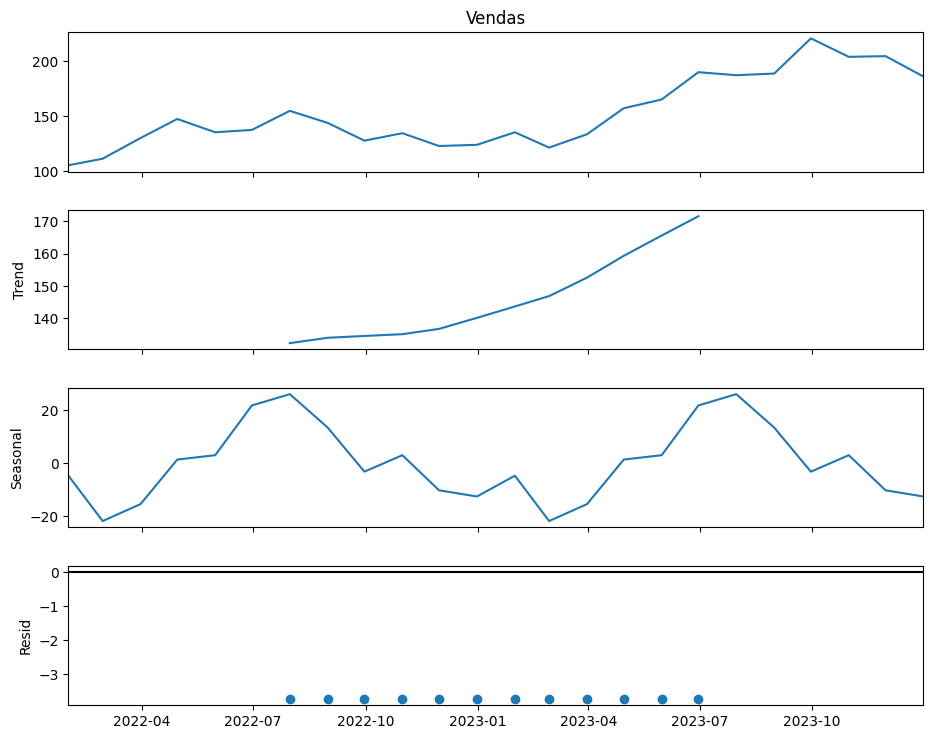

In [3]:
decomposicao = seasonal_decompose(df['Vendas'], model='additive', period=12)

# Plotar componentes
fig = decomposicao.plot()
fig.set_size_inches(10, 8)
plt.show()

## Interpretação e Recomendações
- **Tendência:** Há um crescimento consistente ao longo dos 24 meses.
- **Sazonalidade:** Existem picos e vales claros que se repetem, indicando a necessidade de reforço de estoque em meses específicos.
- **Resíduos:** As variações aleatórias são baixas, o que sugere que o modelo é estável.

# Relatório de Atividade Prática: Análise de Séries Temporais

**1. Introdução e Metodologia**
Nesta atividade, aplicamos técnicas estatísticas em um conjunto de dados de vendas de 24 meses. Utilizamos o Python como ferramenta principal, explorando bibliotecas como Pandas para manipulação e Statsmodels para decomposição analítica. A metodologia focou em transformar dados brutos em informações acionáveis através da identificação de padrões subjacentes.

**2. Experiência e Desenvolvimento**
A geração de dados fictícios permitiu simular um cenário real de negócios onde há crescimento (tendência) e ciclos repetitivos (sazonalidade). A aplicação da **Média Móvel** mostrou-se eficaz para filtrar o ruído de curto prazo, permitindo uma visão mais clara da direção das vendas. Já a **Decomposição Aditiva** foi o ponto crucial para isolar o que é comportamento cíclico do que é crescimento real.

**3. Lições Aprendidas**
- **Previsibilidade:** Entender a sazonalidade permite à empresa planejar promoções e estoque com meses de antecedência.
- **Ruído vs. Sinal:** Nem toda queda nas vendas é motivo de pânico; pode ser apenas um resíduo aleatório ou uma baixa sazonal esperada.
- **Tomada de Decisão:** Modelos de séries temporais reduzem a incerteza no planejamento estratégico, permitindo que a gestão de estoques seja otimizada para evitar custos de excesso ou falta de produtos.

**4. Conclusão**
A prática demonstrou que a análise de dados temporais vai além de simples gráficos de linhas. Ao decompor os dados, ganhamos profundidade analítica que fundamenta decisões logísticas e financeiras mais seguras.